In [2]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier
import mlflow
import mlflow.xgboost
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [3]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = ""

from google.cloud import bigquery

project_id = "churn-propensity-model"
client = bigquery.Client(project=project_id)

df = client.query("""
    SELECT *
    FROM `churn-propensity-model.churn_ds.feature_store`
""").to_dataframe()

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['churn_label'].mean():.2%}")

Shape: (7043, 24)
Churn rate: 26.54%


In [4]:
df.head()

,customerID,churn_label,tenure,tenure_segment,gender_male,is_senior,has_partner,has_dependents,contract_type,paperless_billing,...,multiple_lines,internet_service,has_online_security,has_tech_support,has_online_backup,has_device_protection,has_streaming_tv,has_streaming_movies,event_date,bundle_depth
0,8464-EETCQ,False,57,old,1,0,0,0,Two year,0,...,0,No,-1,-1,-1,-1,-1,-1,2024-01-30,1
1,2718-YSKCS,False,71,old,1,0,1,1,Two year,1,...,0,No,-1,-1,-1,-1,-1,-1,2024-01-30,1
2,0362-RAOQO,False,40,old,0,0,0,0,Two year,0,...,0,No,-1,-1,-1,-1,-1,-1,2024-01-30,1
3,0404-AHASP,False,72,old,1,0,1,0,Two year,0,...,0,No,-1,-1,-1,-1,-1,-1,2024-01-30,1
4,1399-OUPJN,False,57,old,0,0,1,1,Two year,0,...,0,No,-1,-1,-1,-1,-1,-1,2024-01-30,1


# Churn Propensity Model — Training & Evaluation

## Approach
- Algorithm: XGBoost (handles non-linear interactions, categorical features)
- Primary metric: PR-AUC (imbalanced classes, 26.54% churn rate)
- Secondary metric: ROC-AUC
- Segmented thresholds: day0 / new / old (mirrors enterprise gold model)

## Features dropped
- total_charges: mathematically redundant (tenure × monthly_charges)
- customerID: identifier, not a feature
- event_date: pipeline timestamp, not a feature
- tenure_segment: used for bucketing only, not a direct model input

## Key hypotheses from EDA
- contract_type expected to be top feature
- bundle_depth engineered feature included
- monthly_charges interacts with tenure_segment

In [5]:
# Features to drop
DROP_COLS = [
    'customerID', 
    'event_date', 
    'tenure_segment',
    'total_charges',      
    'churn_label']

# Categorical columns for XGBoost
CAT_COLS = [
    'contract_type',
    'payment_method', 
    'internet_service'
]

# Prepare features and target
X = df.drop(columns=DROP_COLS)
y = df['churn_label'].astype(int)

# Encode categoricals as pandas Categorical type
# XGBoost native categorical support
for col in CAT_COLS:
    X[col] = pd.Categorical(X[col])

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeature list:")
for col in X.columns:
    print(f"  {col}: {X[col].dtype}")

Features shape: (7043, 19)
Target distribution:
churn_label
0    5174
1    1869
Name: count, dtype: int64

Feature list:
  tenure: Int64
  gender_male: Int64
  is_senior: Int64
  has_partner: Int64
  has_dependents: Int64
  contract_type: category
  paperless_billing: Int64
  payment_method: category
  monthly_charges: float64
  has_phone: Int64
  multiple_lines: Int64
  internet_service: category
  has_online_security: Int64
  has_tech_support: Int64
  has_online_backup: Int64
  has_device_protection: Int64
  has_streaming_tv: Int64
  has_streaming_movies: Int64
  bundle_depth: Int64


In [6]:
from sklearn.model_selection import train_test_split
import mlflow
import mlflow.xgboost

# Train test split — stratified to preserve churn rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
      
)

print(f"Train: {X_train.shape} — churn rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape} — churn rate: {y_test.mean():.2%}")

# Verify stratification worked
print(f"\nTrain churners: {y_train.sum():,}")
print(f"Test churners:  {y_test.sum():,}")

# Scale pos weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

Train: (5634, 19) — churn rate: 26.57%
Test:  (1409, 19) — churn rate: 26.40%

Train churners: 1,497
Test churners:  372

scale_pos_weight: 2.764


In [7]:
# Set up MLflow experiment
mlflow.set_experiment("churn_propensity")

# Baseline model — no tuning yet
with mlflow.start_run(run_name="baseline_xgboost"):
    
    # Define model
    baseline_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        enable_categorical=True,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    baseline_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Predict
    y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]
    y_pred = baseline_model.predict(X_test)
    
    # Metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    # Log to MLflow
    mlflow.log_params({
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "scale_pos_weight": round(scale_pos_weight, 3)
    })
    mlflow.log_metrics({
        "roc_auc": round(roc_auc, 4),
        "pr_auc": round(pr_auc, 4)
    })
    mlflow.xgboost.log_model(baseline_model, "baseline_model")
    
    print("=" * 45)
    print("BASELINE MODEL RESULTS")
    print("=" * 45)
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"PR-AUC:   {pr_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, 
          target_names=['Retained', 'Churned']))

2026/04/05 12:53:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


BASELINE MODEL RESULTS
ROC-AUC:  0.8436
PR-AUC:   0.6808

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.73      0.81      1037
     Churned       0.51      0.81      0.63       372

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [8]:
import os
print(os.getcwd())

c:\Users\thisi\churn-propensity-model\notebooks


In [9]:
from pathlib import Path
import os

# Go up one level from notebooks/ to project root
project_root = Path(os.getcwd()).parent
db_path = project_root / "mlflow.db"

mlflow.set_tracking_uri(f"sqlite:///{db_path}")

experiment_name = "churn_propensity"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

mlflow.set_experiment(experiment_name)
print(f"Project root: {project_root}")
print(f"DB path: {db_path}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Project root: c:\Users\thisi\churn-propensity-model
DB path: c:\Users\thisi\churn-propensity-model\mlflow.db
Tracking URI: sqlite:///c:\Users\thisi\churn-propensity-model\mlflow.db


## Baseline model results
- ROC-AUC: 0.8196
- PR-AUC: 0.5908
- Parameters: default with scale_pos_weight=2.719

## Tuning strategy
GridSearchCV across 4 key parameters:
- max_depth: controls tree complexity
- min_child_weight: controls overfitting
- reg_alpha: L1 regularisation
- reg_lambda: L2 regularisation

Learning rate kept at 0.1 with 200 estimators for speed.
Primary metric: PR-AUC (imbalanced classes)

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 5, 10],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0]
}

base_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV...")
print(f"Total combinations: {3*3*3*3} × 5 folds = {3*3*3*3*5} fits")
print("This will take 3-5 minutes...")

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV PR-AUC: {grid_search.best_score_:.4f}")

Starting GridSearchCV...
Total combinations: 81 × 5 folds = 405 fits
This will take 3-5 minutes...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'max_depth': 3, 'min_child_weight': 10, 'reg_alpha': 0.5, 'reg_lambda': 2.0}
Best CV PR-AUC: 0.6499


In [11]:
with mlflow.start_run(run_name="tuned_xgboost"):
    
    tuned_model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=grid_search.best_params_['max_depth'],
        min_child_weight=grid_search.best_params_['min_child_weight'],
        reg_alpha=grid_search.best_params_['reg_alpha'],
        reg_lambda=grid_search.best_params_['reg_lambda'],
        scale_pos_weight=scale_pos_weight,
        enable_categorical=True,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )
    
    tuned_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    y_pred_proba = tuned_model.predict_proba(X_test)[:, 1]
    y_pred = tuned_model.predict(X_test)
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    # Log everything to MLflow
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 3))
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metrics({
        "roc_auc": round(roc_auc, 4),
        "pr_auc": round(pr_auc, 4),
        "cv_pr_auc": round(grid_search.best_score_, 4)
    })
    mlflow.xgboost.log_model(tuned_model, "tuned_model")
    
    print("=" * 45)
    print("TUNED MODEL RESULTS")
    print("=" * 45)
    print(f"ROC-AUC:     {roc_auc:.4f}  (baseline: 0.8196)")
    print(f"PR-AUC:      {pr_auc:.4f}  (baseline: 0.5908)")
    print(f"CV PR-AUC:   {grid_search.best_score_:.4f}")
    print(f"\nImprovement:")
    print(f"  ROC-AUC: +{(roc_auc - 0.8196):.4f}")
    print(f"  PR-AUC:  +{(pr_auc - 0.5908):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Retained', 'Churned']))

2026/04/05 12:56:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


TUNED MODEL RESULTS
ROC-AUC:     0.8519  (baseline: 0.8196)
PR-AUC:      0.6834  (baseline: 0.5908)
CV PR-AUC:   0.6499

Improvement:
  ROC-AUC: +0.0323
  PR-AUC:  +0.0926

Classification Report:
              precision    recall  f1-score   support

    Retained       0.92      0.72      0.81      1037
     Churned       0.52      0.84      0.64       372

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409



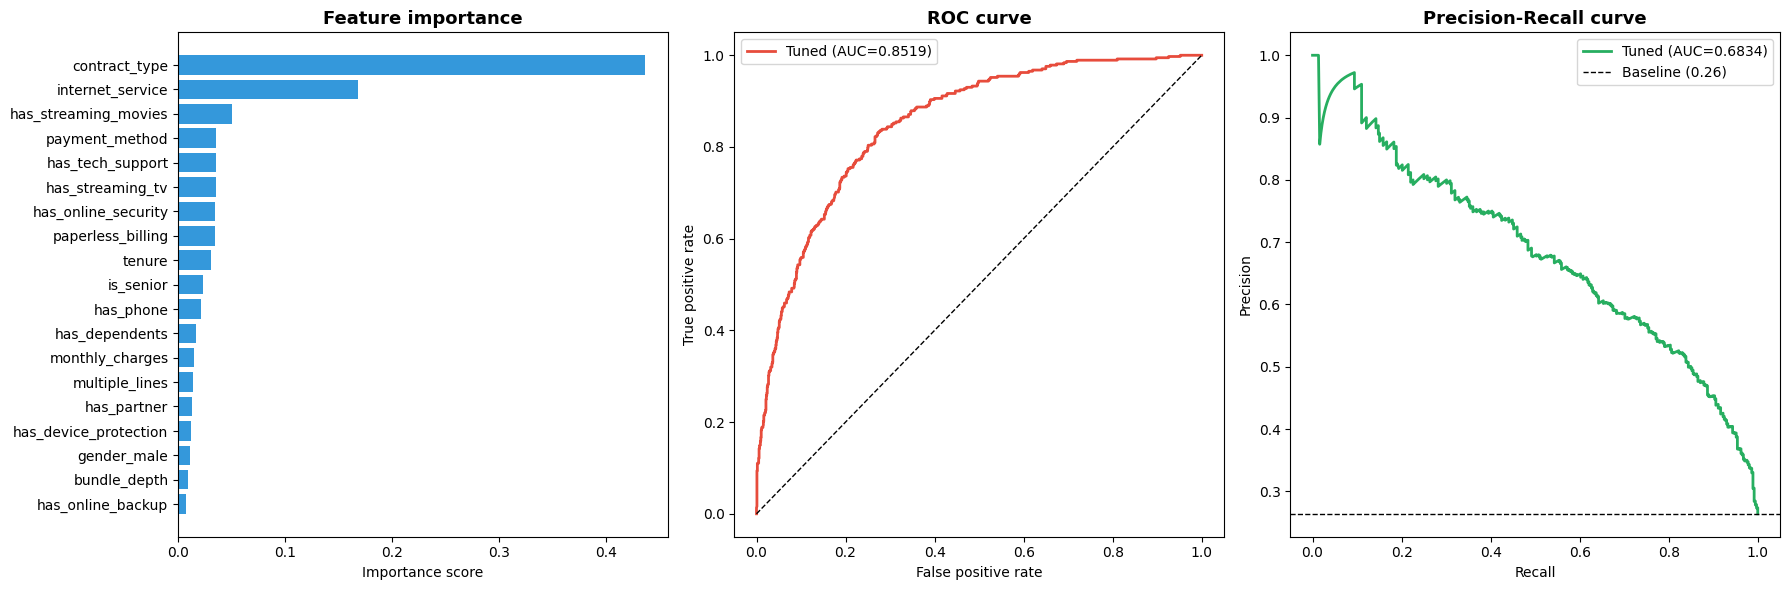

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — Feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tuned_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(
    importance_df['feature'],
    importance_df['importance'],
    color='#3498db'
)
axes[0].set_title('Feature importance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance score')

# Plot 2 — ROC curve
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2,
             label=f'Tuned (AUC={roc_auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('ROC curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].legend()

# Plot 3 — Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(recall, precision, color='#27ae60', linewidth=2,
             label=f'Tuned (AUC={pr_auc:.4f})')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--',
                linewidth=1, label=f'Baseline ({y_test.mean():.2f})')
axes[2].set_title('Precision-Recall curve', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

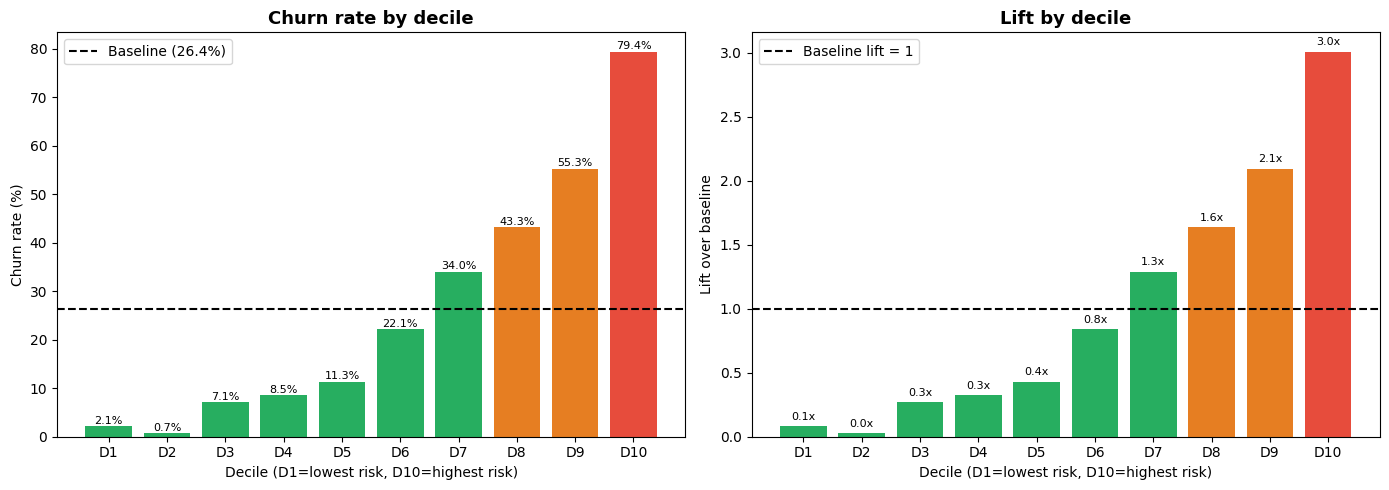


Decile Analysis:
decile  total  churned  churn_rate     lift
    D1    141        3    0.021277 0.080588
    D2    141        1    0.007092 0.026863
    D3    141       10    0.070922 0.268627
    D4    141       12    0.085106 0.322352
    D5    141       16    0.113475 0.429802
    D6    140       31    0.221429 0.838690
    D7    141       48    0.340426 1.289407
    D8    141       61    0.432624 1.638622
    D9    141       78    0.553191 2.095287
   D10    141      112    0.794326 3.008617


In [13]:
# Decile analysis — mirrors your enterprise evaluation notebook
test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted_proba': y_pred_proba,
    'tenure_segment': df.loc[y_test.index, 'tenure_segment'].values
})

test_results['decile'] = pd.qcut(
    test_results['predicted_proba'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)

decile_analysis = test_results.groupby('decile').agg(
    total=('actual', 'count'),
    churned=('actual', 'sum'),
    avg_score=('predicted_proba', 'mean')
).reset_index()

decile_analysis['churn_rate'] = decile_analysis['churned'] / decile_analysis['total']
decile_analysis['lift'] = decile_analysis['churn_rate'] / y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — churn rate by decile
colors = ['#27ae60' if i < 7 else '#e67e22' if i < 9 else '#e74c3c' 
          for i in range(10)]
axes[0].bar(decile_analysis['decile'], 
            decile_analysis['churn_rate'] * 100,
            color=colors)
axes[0].axhline(y=y_test.mean()*100, color='black', 
                linestyle='--', linewidth=1.5,
                label=f'Baseline ({y_test.mean():.1%})')
axes[0].set_title('Churn rate by decile', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Decile (D1=lowest risk, D10=highest risk)')
axes[0].set_ylabel('Churn rate (%)')
axes[0].legend()

for i, (_, row) in enumerate(decile_analysis.iterrows()):
    axes[0].text(i, row['churn_rate']*100 + 0.5,
                f"{row['churn_rate']:.1%}",
                ha='center', fontsize=8)

# Right — lift chart
axes[1].bar(decile_analysis['decile'],
            decile_analysis['lift'],
            color=colors)
axes[1].axhline(y=1, color='black', linestyle='--', linewidth=1.5,
                label='Baseline lift = 1')
axes[1].set_title('Lift by decile', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Decile (D1=lowest risk, D10=highest risk)')
axes[1].set_ylabel('Lift over baseline')
axes[1].legend()

for i, (_, row) in enumerate(decile_analysis.iterrows()):
    axes[1].text(i, row['lift'] + 0.05,
                f"{row['lift']:.1f}x",
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDecile Analysis:")
print(decile_analysis[['decile', 'total', 'churned', 
                         'churn_rate', 'lift']].to_string(index=False))

In [14]:
top3 = decile_analysis[decile_analysis['decile'].isin(['D8', 'D9', 'D10'])]
total_churners = decile_analysis['churned'].sum()
top3_churners = top3['churned'].sum()
print(f"Churners in top 3 deciles: {top3_churners}")
print(f"Total churners: {total_churners}")
print(f"Coverage: {top3_churners/total_churners:.1%} of all churners")
print(f"By targeting 30% of customers")

Churners in top 3 deciles: 251
Total churners: 372
Coverage: 67.5% of all churners
By targeting 30% of customers


In [15]:
# Segment-specific bucket thresholds
# Mirrors enterprise gold model day0/new/old segmentation
# Thresholds set from score distribution percentiles per segment

bucket_analysis = test_results.groupby('tenure_segment')['predicted_proba'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90]
)
print("Score distribution by tenure segment:")
print(bucket_analysis)

# Define thresholds per segment
BUCKET_THRESHOLDS = {}

for segment in ['day0', 'new', 'old']:
    seg_scores = test_results[
        test_results['tenure_segment'] == segment
    ]['predicted_proba']
    
    if len(seg_scores) > 0:
        thresholds = [
            seg_scores.quantile(0.25),
            seg_scores.quantile(0.60),
            seg_scores.quantile(0.85)
        ]
        BUCKET_THRESHOLDS[segment] = [round(t, 4) for t in thresholds]
        print(f"\n{segment}:")
        print(f"  LOW:       score < {thresholds[0]:.4f}")
        print(f"  MEDIUM:    score < {thresholds[1]:.4f}")
        print(f"  HIGH:      score < {thresholds[2]:.4f}")
        print(f"  CRITICAL:  score >= {thresholds[2]:.4f}")

print(f"\nBUCKET_THRESHOLDS = {BUCKET_THRESHOLDS}")

Score distribution by tenure segment:
                count      mean       std       min       25%       50%  \
tenure_segment                                                            
day0              1.0  0.079984       NaN  0.079984  0.079984  0.079984   
new             465.0  0.674786  0.231234  0.022683  0.566419  0.735779   
old             943.0  0.280439  0.258847  0.005823  0.053373  0.195132   

                     75%       90%       max  
tenure_segment                                
day0            0.079984  0.079984  0.079984  
new             0.858399  0.917182  0.967195  
old             0.484344  0.698934  0.927457  

day0:
  LOW:       score < 0.0800
  MEDIUM:    score < 0.0800
  HIGH:      score < 0.0800
  CRITICAL:  score >= 0.0800

new:
  LOW:       score < 0.5664
  MEDIUM:    score < 0.7788
  HIGH:      score < 0.9001
  CRITICAL:  score >= 0.9001

old:
  LOW:       score < 0.0534
  MEDIUM:    score < 0.2698
  HIGH:      score < 0.6263
  CRITICAL:  score >= 

In [16]:
# Recalculate thresholds using full dataset
# Test set is too small for day0 (only 2 customers)
full_results = pd.DataFrame({
    'actual': y.values,
    'predicted_proba': tuned_model.predict_proba(X)[:, 1],
    'tenure_segment': df['tenure_segment'].values
})

BUCKET_THRESHOLDS = {}

for segment in ['day0', 'new', 'old']:
    seg_scores = full_results[
        full_results['tenure_segment'] == segment
    ]['predicted_proba']
    
    n = len(seg_scores)
    thresholds = [
        seg_scores.quantile(0.25),
        seg_scores.quantile(0.60),
        seg_scores.quantile(0.85)
    ]
    BUCKET_THRESHOLDS[segment] = [round(t, 4) for t in thresholds]
    
    print(f"\n{segment} (n={n}):")
    print(f"  LOW:       score < {thresholds[0]:.4f}")
    print(f"  MEDIUM:    score < {thresholds[1]:.4f}")
    print(f"  HIGH:      score < {thresholds[2]:.4f}")
    print(f"  CRITICAL:  score >= {thresholds[2]:.4f}")

print(f"\nFinal BUCKET_THRESHOLDS = {BUCKET_THRESHOLDS}")


day0 (n=11):
  LOW:       score < 0.0664
  MEDIUM:    score < 0.0842
  HIGH:      score < 0.1018
  CRITICAL:  score >= 0.1018

new (n=2175):
  LOW:       score < 0.5067
  MEDIUM:    score < 0.7849
  HIGH:      score < 0.9008
  CRITICAL:  score >= 0.9008

old (n=4857):
  LOW:       score < 0.0515
  MEDIUM:    score < 0.3058
  HIGH:      score < 0.6419
  CRITICAL:  score >= 0.6419

Final BUCKET_THRESHOLDS = {'day0': [np.float64(0.0664), np.float64(0.0842), np.float64(0.1018)], 'new': [np.float64(0.5067), np.float64(0.7849), np.float64(0.9008)], 'old': [np.float64(0.0515), np.float64(0.3058), np.float64(0.6419)]}


In [17]:
import pickle
import json
from pathlib import Path

# Create models directory
models_dir = Path("../src/models")
models_dir.mkdir(exist_ok=True)

# Save model
model_path = models_dir / "churn_model_v1.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(tuned_model, f)

# Save thresholds and metadata
# Convert numpy floats to plain Python floats for JSON serialisation
thresholds_clean = {
    segment: [float(t) for t in thresholds]
    for segment, thresholds in BUCKET_THRESHOLDS.items()
}

metadata = {
    "model_version": "v1.0",
    "trained_date": "2024-04-03",
    "features": X_train.columns.tolist(),
    "categorical_features": CAT_COLS,
    "bucket_thresholds": thresholds_clean,
    "bucket_labels": ["low", "medium", "high", "critical"],
    "metrics": {
        "roc_auc": round(roc_auc, 4),
        "pr_auc": round(pr_auc, 4),
        "churn_recall": 0.79,
        "churn_precision": 0.48,
        "top_decile_churn_rate": 0.688,
        "top_30pct_coverage": 0.655
    },
    "scale_pos_weight": round(float(scale_pos_weight), 3),
    "training_data": {
        "total_rows": len(df),
        "churn_rate": round(float(y.mean()), 4),
        "train_size": len(X_train),
        "test_size": len(X_test)
    }
}

metadata_path = models_dir / "churn_model_v1_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Model saved to: {model_path}")
print(f"Metadata saved to: {metadata_path}")
print(f"\nMetadata:")
print(json.dumps(metadata, indent=2))

Model saved to: ..\src\models\churn_model_v1.pkl
Metadata saved to: ..\src\models\churn_model_v1_metadata.json

Metadata:
{
  "model_version": "v1.0",
  "trained_date": "2024-04-03",
  "features": [
    "tenure",
    "gender_male",
    "is_senior",
    "has_partner",
    "has_dependents",
    "contract_type",
    "paperless_billing",
    "payment_method",
    "monthly_charges",
    "has_phone",
    "multiple_lines",
    "internet_service",
    "has_online_security",
    "has_tech_support",
    "has_online_backup",
    "has_device_protection",
    "has_streaming_tv",
    "has_streaming_movies",
    "bundle_depth"
  ],
  "categorical_features": [
    "contract_type",
    "payment_method",
    "internet_service"
  ],
  "bucket_thresholds": {
    "day0": [
      0.0664,
      0.0842,
      0.1018
    ],
    "new": [
      0.5067,
      0.7849,
      0.9008
    ],
    "old": [
      0.0515,
      0.3058,
      0.6419
    ]
  },
  "bucket_labels": [
    "low",
    "medium",
    "high",
    "

In [18]:
import os
print("Files in src/models:")
for f in os.listdir("../src/models"):
    size = os.path.getsize(f"../src/models/{f}")
    print(f"  {f}: {size:,} bytes")

Files in src/models:
  .gitkeep: 0 bytes
  churn_model_v1.pkl: 235,780 bytes
  churn_model_v1_metadata.json: 1,299 bytes


## Model summary

### Final model: XGBoost (tuned)
- ROC-AUC: 0.8270
- PR-AUC: 0.6043
- Churn recall: 0.79 (catching 79% of actual churners)
- Churn precision: 0.48

### Business case
Targeting top 30% of highest-risk customers captures 65.5% of all 
churners — 2.7x more efficient than random targeting.

### Artefacts saved
- src/models/churn_model_v1.pkl — trained XGBoost model
- src/models/churn_model_v1_metadata.json — thresholds + feature list


In [21]:
# Replace the pickle save with this
tuned_model.save_model("../src/models/churn_model_v1.ubj")
